# Глава 2. Архитектура и компоненты

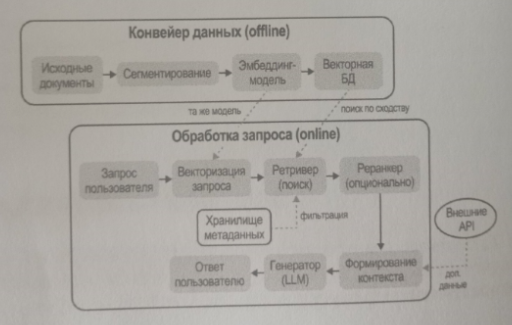

## 2.1. Основные компоненты RAG‑систем

### Общая логика архитектуры

Схема отражает два основных потока:  
* **офлайн‑подготовку данных** — формирует основу знаний системы; качество этого этапа задаёт верхний предел эффективности RAG;  
* **онлайн‑обработку запросов** — отвечает за скорость ответа и пользовательский опыт.

### Конвейер данных: офлайн‑подготовка

Этот этап создаёт базу знаний для RAG‑системы и включает последовательные шаги:

1. **Загрузка и нормализация исходных документов** из разнородных источников: текстовых файлов, PDF, веб‑страниц, записей из баз данных. Для работы с разными форматами требуются универсальные загрузчики, способные извлекать чистый текст.  
2. **Сегментирование (чанкирование)** — разбиение документов на логически связанные фрагменты оптимального размера (обычно 100–1000 токенов). Критически важно соблюсти баланс: слишком маленькие чанки теряют контекст, слишком большие могут содержать разнородную информацию, снижающую точность поиска.  
3. **Преобразование в эмбеддинги** с помощью эмбеддинг‑модели: текстовые фрагменты кодируются в числовые векторы, отражающие их семантическое содержание. Выбор модели критичен — она должна эффективно работать с предметной областью и языком документов.  
4. **Хранение в векторной базе данных**, оптимизированной для быстрого поиска высокомерных векторов. Среди современных решений упоминаются Pinecone, Weaviate, Qdrant, Chroma — они предлагают разные компромиссы между скоростью, точностью и функциональностью.

### Обработка запросов: онлайн‑поток

При поступлении пользовательского запроса система выполняет следующие действия:

* **Векторизация запроса** с использованием той же эмбеддинг‑модели, что применялась при индексации документов. Это обеспечивает совместимость векторных представлений и корректность поиска по сходству.  
* **Работа ретривера (retriever)** — семантический поиск в векторном пространстве для нахождения K наиболее похожих фрагментов. Современные ретриверы поддерживают гибридный поиск, комбинируя векторное сходство с лексическими методами (например, BM25) для повышения точности.  
* **Опциональная работа реранкера (reranker)** — специализированные модели анализируют найденные фрагменты в контексте конкретного запроса и переранжируют их, более точно оценивая релевантность. Это особенно эффективно при работе со сложными или многоаспектными запросами.

### Дополнительные компоненты

В архитектуре также задействованы:  
* хранилище метаданных (с функцией фильтрации);  
* внешние API (для получения дополнительных данных);  
* генератор на базе LLM — формирует итоговый ответ пользователю на основе собранного контекста.

### Формирование контекста и генерация

На этом этапе система превращает найденные фрагменты в осмысленный ответ:

* **Модуль аугментации (augmentation)** объединяет релевантные фрагменты с исходным запросом пользователя, формируя расширенный промпт для языковой модели. В рамках аугментации часто выполняют дополнительную обработку: сжатие контекста (чтобы уложиться в лимиты токенов), удаление дубликатов и структурирование информации (например, в виде списка или JSON).  
* **Генератор (LLM)** получает обогащённый контекст и формирует финальный ответ. Ключевое преимущество такого подхода — модель опирается не только на свои параметрические знания (заложенные при обучении), но и на предоставленную актуальную информацию. Это существенно снижает количество галлюцинаций и повышает достоверность ответа.

### Дополнительные компоненты

Эти модули расширяют функциональность и встраивают RAG в корпоративную среду:

* **Хранилище метаданных** дополняет поиск атрибутами документов: дата создания, автор, категория, права доступа. Это позволяет фильтровать результаты и обеспечивать релевантность на уровне бизнес‑логики (например, показывать только документы с уровнем допуска «для сотрудников отдела»).  
* **Внешние API** интегрируют RAG с корпоративными системами (CRM, ERP) и внешними сервисами, превращая его в универсальный интерфейс к экосистеме данных.  
* **Подсистема мониторинга и журналирования** отслеживает качество работы каждого компонента. В неё входят метрики производительности, анализ пользовательской активности и A/B‑тестирование разных конфигураций. Хотя эта подсистема не показана на архитектурных диаграммах (она как бы охватывает все компоненты), она критически важна для непрерывного улучшения системы.

### Модульность и масштабируемость

Это ключевое преимущество RAG‑архитектуры:

* **Независимое масштабирование.** Каждый компонент можно оптимизировать отдельно: эмбеддинг‑модель — заменить на более эффективную, векторную БД — масштабировать горизонтально, ретривер — настроить под специфику предметной области.  
* **Итеративное развитие.** Архитектура позволяет начать с простой реализации и постепенно наращивать сложность: добавлять реранкинг, гибридный поиск, поддержку мультимодальных данных или агентские возможности. Такой подход делает RAG идеальной технологией для развивающихся продуктов.  

Понимание роли каждого компонента и принципов их взаимодействия — основа для проектирования эффективных RAG‑систем. В следующих разделах книги рассматриваются архитектурные паттерны и методы интеграции этих компонентов в единую высокопроизводительную систему.

## 2.2. Архитектурные паттерны: от классики к автономным системам

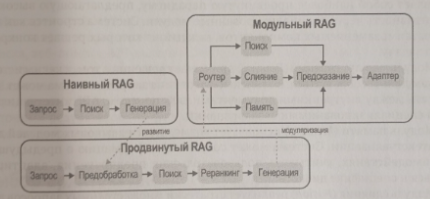

За несколько лет появилось несколько разных архитектур RAG. Каждая решает свои задачи и выбирает свой баланс между простотой, эффективностью и возможностями.

**Эволюция архитектур**

Развитие шло от понимания слабых мест простых систем к созданию более сложных и гибких. Каждый новый тип наследует удачные решения предыдущего и добавляет что-то своё.

**Наивный RAG**

Это самая простая схема: документы режутся на куски, переводятся в векторы и сохраняются. По запросу система находит похожие куски и отдаёт их языковой модели вместе с вопросом.

*Плюсы:* легко сделать, предсказуемо работает, просто отлаживать. Для простых задач (FAQ-боты, техподдержка) этого достаточно.

*Минусы:* не справляется со сложными вопросами, где нужно собрать информацию из разных мест. Нет контроля над качеством поиска — в ответ может попасть мусор.

**Продвинутый RAG**

Добавляет обработку запроса до и после поиска, чтобы улучшить результат.

*Что делает до поиска:*
- Расширяет запрос синонимами, разбивает на части или переформулирует, чтобы лучше совпадало с документами.
- Улучшает индексацию: режет текст с перекрытием, сохраняет иерархию кусков, добавляет метаданные. Так контекст не теряется и поиск становится точнее.

*Что делает после поиска:*
- **Реранкинг** — специальная модель перепроверяет найденные куски и перестраивает их по настоящей полезности для конкретного запроса (кросс-энкодеры сильно поднимают качество).
- **Гибридный поиск** — смешивает векторный и текстовый поиск (например, BM25) и объединяет результаты через Reciprocal Rank Fusion (RRF), беря лучшее от обоих методов.

---
**BM25** — это формула ранжирования, которая оценивает релевантность документа запросу по «мешку слов». Принцип: чем чаще редкие слова запроса встречаются в документе, тем выше вес, но с насыщением (много повторов не дают бесконечного роста), с поправкой на длину документа.

**Reciprocal Rank Fusion (RRF)** — это метод слияния нескольких ранжированных списков в один. Принцип: итоговый score элемента = сумма обратных величин его позиций в каждом из списков (`1 / (k + rank)`). Позиции в топе дают основной вклад, а аутсайдеры почти не влияют.

---

**Модульный RAG**

Самая гибкая система, собранная из сменных блоков под разные задачи.

- **Маршрутизация (Routing)** — решает, куда идти за ответом: внутренние документы, интернет, API или специальная база знаний.
- **Память (Memory)** — запоминает историю общения, учитывает предпочтения пользователя и адаптируется по ходу диалога.
- **Слияние (Fusion)** — превращает один запрос в несколько разных формулировок, ищет по каждой, а затем объединяет и фильтрует результаты для большей полноты.
- **Предсказание** — модель сама достраивает контекст запроса, «додумывая» недостающее, чтобы искать по более полной картине.

**Агентный RAG**

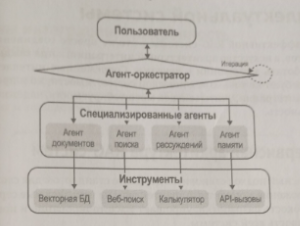

Это следующий шаг — системы, которые сами планируют, адаптируются и улучшают результат по ходу дела, а не идут по жёсткому сценарию.

*Как устроено (по схеме):*
- Пользователь общается с **агентом-оркестратором**, который может делать итерации.
- Оркестратор управляет **специализированными агентами**: по документам, поиску, рассуждениям, памяти.
- Те, в свою очередь, используют **инструменты**: векторную базу, веб-поиск, калькулятор, вызовы API.

*Моноагентный RAG* — частный случай, где один агент-оркестратор на лету решает, какой инструмент применить под конкретный запрос. Никакого заранее прописанного маршрута.

**Сильные стороны агентных систем:**
- **Автономность** — сами решают, что делать.
- **Адаптивность** — меняют стратегию по промежуточным результатам.
- **Проактивность** — предугадывают потребности пользователя и справляются с многоэтапными задачами.

**Как выбирать архитектуру:**

- **Наивный RAG** — простые задачи, маленький бюджет.
- **Продвинутый RAG** — когда важно высокое качество ответов.
- **Модульный RAG** — сложные корпоративные системы с кучей разных источников данных.
- **Агентные архитектуры** — сложная аналитика, много источников, меняющиеся условия. Разработка и поддержка ощутимо дороже.

**Общий вектор развития:** RAG-архитектуры становятся всё более автономными, специализированными и гибкими, чтобы точнее закрывать бизнес-задачи.

## 2.3. Интеграция компонентов интеллектуальной системы

**Интеграция компонентов — это не просто сборка**

Мало соединить готовые детали. Нужно, чтобы всё работало слаженно, с учётом масштабируемости, надёжности и производительности.

**Микросервисная архитектура — стандарт для сложных RAG-систем**

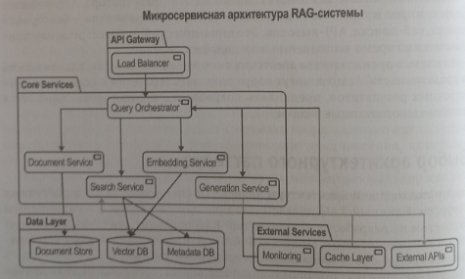

Вместо одного монолита систему разбивают на независимые сервисы. Это даёт гибкость, упрощает расширение и повышает устойчивость к сбоям.

*Ключевые блоки (по схеме):*
- **API Gateway** и **Load Balancer** — вход и распределение нагрузки.
- **Core Services** — ядро: оркестратор запросов, сервисы документов, эмбеддингов, поиска и генерации.
- **Data Layer** — хранение: документы, векторная база, метаданные.
- **Внешние штуки** — мониторинг, кэш, внешние API.

*Плюсы:* 
- Каждый сервис отвечает за свою задачу и может разрабатываться отдельной командой на своём стеке технологий;
- Можно масштабировать только то, что нужно, а не всю систему целиком.
- Сбой в одном сервисе не валит всё остальное.

**Паттерны интеграции: синхронность и асинхронность**

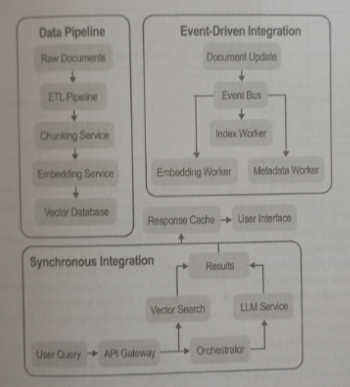

Выбор между синхронными и асинхронными паттернами интеграции — одно из ключевых архитектурных решений. Каждый подход имеет свои области применения и компромиссы.

**Два способа связи: синхронный и асинхронный**

Это важный выбор, у каждого варианта свои плюсы и минусы.

**Синхронная интеграция — для быстрых ответов**

Подходит, когда пользователь ждёт результат сразу: запросы, живой поиск, интерактив. Цепочка: запрос → API-шлюз → оркестратор → поиск + языковая модель → ответ (возможно, из кэша). Просто отлаживать, поток данных предсказуем.

**Асинхронная интеграция — для фоновой обработки**

Подходит для тяжёлых задач: индексация документов, обновление эмбеддингов, аналитика. Работает через события и шину событий, отдельные рабочие процессы занимаются индексацией, эмбеддингами, метаданными. Высокая производительность и надёжность, но сложнее управлять состояниями.

**Оркестрация процессов: дирижёр интеллектуальной системы**

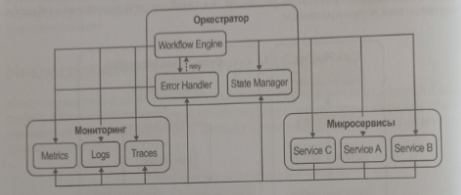

Оркестратор — центр управления RAG-системой

Он не просто дёргает сервисы по очереди, а умно управляет всем процессом.

**Три ключевые части оркестратора:**

- **Workflow Engine (движок процессов)** — управляет логикой выполнения. Может ветвить процесс, запускать параллельные задачи, зацикливать и ставить на паузу. Например, сам решает, какую стратегию поиска выбрать под тип запроса или как гибко управлять контекстом для генерации.

- **State Manager (менеджер состояний)** — следит за всеми активными процессами. Нужен, чтобы восстановиться после сбоя и корректно обрабатывать долгие операции (например, индексацию кучи документов или итеративное уточнение запроса).

- **Error Handler (обработчик ошибок)** — решает, что делать при сбоях: от простого повтора до сложных обходных манёвров. Может сам переключиться на запасной источник данных или другую модель, если основное недоступно.

**Стратегии управления данными**

**Управление данными** — нужно найти баланс между тремя вещами: согласованность данных, их доступность и скорость работы.

**Мониторинг и оповещения:**
- Метрики следят за инфраструктурой: нагруженность, пропускная способность, доступность сервисов.
- При проблемах система сама бьёт тревогу и может автоматически: расширить перегруженные компоненты, переключиться на резервные источники данных или временно урезать сложные запросы, чтобы удержать стабильность.

**Итог:** хорошая интеграция RAG-системы — это баланс между технической красотой и реальными бизнес-задачами. Понимание архитектурных паттернов, способов связи компонентов и методов контроля качества даёт базу для построения надёжных, расширяемых и удобных в поддержке умных систем.

## 2.4. Практический пример создания простейшей RAG‑системы

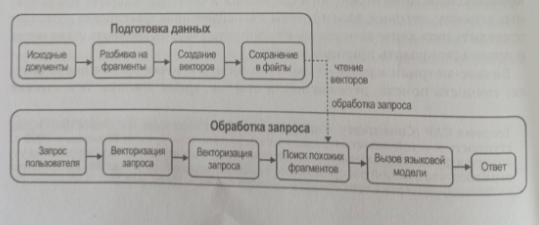

### Установка зависимостей

In [1]:
pip install sentence-transformers numpy openai requests beautifulsoup4

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Этап 1: подготовка базы знаний. Создадим класс для подготовки и индексации документов

In [2]:
import numpy as np
from sentence_transformers import SentenceTransformer
import json
import re
from typing import List, Dict

class DataPreparation:
    def __init__(self, embedding_model='all-MiniLM-L6-v2'):
        # Загружаем модель для создания векторных представлений
        self.model = SentenceTransformer(embedding_model)
        self.chunks = []
        self.vectors = None

    def split_into_chunks(self, text: str, chunk_size=500, overlap=50) -> List[str]:
        """Разбиваем текст на логические фрагменты с перекрытием"""
        words = text.split()
        chunks = []

        for i in range(0, len(words), chunk_size - overlap):
            chunk = ' '.join(words[i:i + chunk_size])
            if len(chunk.strip()) > 50:  # Игнорируем слишком короткие фрагменты
                chunks.append(chunk.strip())

        return chunks

    def process_documents(self, documents: List[str]):
        """Обрабатываем список документов"""
        print("Разбиваем документы на фрагменты...")

        for i, document in enumerate(documents):
            doc_chunks = self.split_into_chunks(document)

            # Сохраняем фрагменты с метаинформацией
            for j, chunk in enumerate(doc_chunks):
                self.chunks.append({
                    'text': chunk,
                    'document_id': i,
                    'chunk_id': j,
                    'length': len(chunk)
                })

        print(f"Создано {len(self.chunks)} фрагментов")

        # Создаём векторные представления
        print("Создаём векторные представления...")
        chunk_texts = [chunk['text'] for chunk in self.chunks]
        self.vectors = self.model.encode(chunk_texts)
        print(f"Создано {len(self.vectors)} векторов размерности {self.vectors.shape}")

    def save_knowledge_base(self, base_path='knowledge_base'):
        """Сохраняем базу знаний в файлы"""
        # Сохраняем фрагменты
        with open(f'{base_path}_chunks.json', 'w', encoding='utf-8') as f:
            json.dump(self.chunks, f, ensure_ascii=False, indent=2)

        # Сохраняем векторы
        np.save(f'{base_path}_vectors.npy', self.vectors)
        print(f"База знаний сохранена в файлы {base_path}_*")

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Этап 2: поисковая система. Создадим класс для семантического поиска по базе знаний

In [3]:
class SearchSystem:
    def __init__(self, base_path='knowledge_base', embedding_model='all-MiniLM-L6-v2'):
        # Загружаем сохранённую базу знаний
        self.model = SentenceTransformer(embedding_model)

        # Загружаем фрагменты
        with open(f'{base_path}_chunks.json', 'r', encoding='utf-8') as f:
            self.chunks = json.load(f)

        # Загружаем векторы
        self.vectors = np.load(f'{base_path}_vectors.npy')
        print(f"Загружена база знаний: {len(self.chunks)} фрагментов")

    def find_similar(self, query: str, top_k=3) -> List[Dict]:
        """Находим наиболее релевантные фрагменты"""
        # Векторизуем запрос
        query_vector = self.model.encode([query])

        # Вычисляем косинусное сходство
        similarities = np.dot(self.vectors, query_vector.T).flatten()
        base_norms = np.linalg.norm(self.vectors, axis=1)
        query_norm = np.linalg.norm(query_vector)
        cosine_similarities = similarities / (base_norms * query_norm)

        # Находим индексы наиболее похожих фрагментов
        top_indices = np.argsort(cosine_similarities)[-top_k:][::-1]

        # Формируем результат
        results = []
        for idx in top_indices:
            result = self.chunks[idx].copy()
            result['similarity'] = float(cosine_similarities[idx])
            results.append(result)

        return results

Косинусное сходство — основа семантического поиска. Чем ближе к 1 значение сходства, тем больше запрос похож на фрагмент по смыслу. Мы возвращаем не просто тексты, а полную информацию о найденных фрагментах для дальнейшего анализа.

### Этап 3: генерация ответов. Создадим класс для интеграции с языковой моделью

In [4]:
pip install gigachat

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from gigachat import GigaChat
from typing import List, Dict

class AnswerGenerator:
    def __init__(self, api_key: str):
        """Инициализация клиента GigaChat"""
        self.client = GigaChat(
            credentials=api_key,
            verify_ssl_certs=False  # Отключаем проверку SSL сертификатов
        )
        self.system_message = """Ты — помощник, который отвечает на вопросы, опираясь строго на предоставленный контекст.

Правила:
1. Используй только информацию из контекста.
2. Если ответа нет в контексте, честно скажи об этом.
3. Указывай степень уверенности в ответе.
4. Будь кратким и точным"""

    def create_prompt(self, query: str, chunks: List[Dict]) -> str:
        """Формируем промпт с контекстом"""
        context = ""
        for i, chunk in enumerate(chunks, 1):
            similarity_percent = int(chunk['similarity'] * 100)
            context += f"\n--- Фрагмент {i} (релевантность {similarity_percent}%) ---\n"
            context += chunk['text']
            context += "\n"

        prompt = f"""Контекст:
{context}
Вопрос: {query}
Ответ:"""
        return prompt

    def get_answer(self, query: str, chunks: List[Dict]) -> str:
        """Генерируем ответ с помощью GigaChat"""
        prompt = self.create_prompt(query, chunks)
        try:
            # Правильный синтаксис для GigaChat SDK
            response = self.client.chat(prompt)
            return response.choices[0].message.content.strip()
        except Exception as error:
            return f"Ошибка при генерации ответа: {str(error)}"

Промпт‑инженерия критически важна для качества RAG‑системы. Мы явно указываем модели ограничиваться предоставленным контекстом и показываем релевантность каждого фрагмента.

### Этап 4: объединение всех компонентов. Создадим основной класс RAG‑системы

In [6]:
class RAGSystem:
    def __init__(self, api_key: str, base_path='knowledge_base'):
        self.search = SearchSystem(base_path)
        self.generator = AnswerGenerator(api_key)

    def answer(self, question: str, num_chunks=3) -> Dict:
        """Основная функция: поиск + генерация ответа"""
        print(f"Обрабатываем вопрос: {question}")

        # Находим релевантные фрагменты
        chunks = self.search.find_similar(question, num_chunks)
        print("\nНайденные фрагменты:")
        for i, chunk in enumerate(chunks, 1):
            similarity = int(chunk['similarity'] * 100)
            preview = chunk['text'][:100] + "..."
            print(f"{i}. Сходство {similarity}%: {preview}")

        # Генерируем ответ
        answer = self.generator.get_answer(question, chunks)

        return {
            'question': question,
            'answer': answer,
            'sources': chunks,
            'num_sources': len(chunks)
        }

# Пример использования
if __name__ == "__main__":
    # Подготавливаем тестовые документы
    documents = [
        "Python — высокоуровневый язык программирования общего назначения. Создан в 1991 году Гвидо ван Россумом в Центре математики и информатики в Нидерландах.",
        "RAG, или генерация с дополненной выборкой, — это архитектурный подход в обработке естественного языка, который объединяет поиск информации с генерацией текста.",
        "Векторные базы данных специально разработаны для хранения и поиска высокомерных векторов. Они используют специальные алгоритмы индексирования для быстрого поиска похожих векторов."
    ]

    # Создаём и сохраняем базу знаний
    data_prep = DataPreparation()
    data_prep.process_documents(documents)
    data_prep.save_knowledge_base()

    # Создаём RAG‑систему с правильным API ключом
    # ВАЖНО: Замените на ваш реальный ключ или используйте переменные окружения
    rag = RAGSystem(api_key="OWU5ZmY0NzItNjQ5NS00Y2FmLTkzZjMtZjNmZmM4ZTA3ZGM2OjZkMWUwMzFiLTNkNTUtNGU0ZS1iZTY2LWYwNWM3NzkyZDkyNQ==")

    # Задаём вопросы
    questions = [
        "Кто создал Python?",
        "Что такое RAG?",
        "Как работают векторные базы данных?"
    ]

    for question in questions:
        result = rag.answer(question)
        print(f"\nВопрос: {result['question']}")
        print(f"Ответ: {result['answer']}")
        print("-" * 60)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12876.70it/s]


Разбиваем документы на фрагменты...
Создано 3 фрагментов
Создаём векторные представления...
Создано 3 векторов размерности (3, 384)
База знаний сохранена в файлы knowledge_base_*


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12875.17it/s]


Загружена база знаний: 3 фрагментов
Обрабатываем вопрос: Кто создал Python?

Найденные фрагменты:
1. Сходство 62%: Python — высокоуровневый язык программирования общего назначения. Создан в 1991 году Гвидо ван Россу...
2. Сходство 41%: RAG, или генерация с дополненной выборкой, — это архитектурный подход в обработке естественного язык...
3. Сходство 38%: Векторные базы данных специально разработаны для хранения и поиска высокомерных векторов. Они исполь...

Вопрос: Кто создал Python?
Ответ: **Анализ фрагментов**

- **Фрагмент 1**: Содержит релевантную информацию о создании Python Гвидо ван Россумом в 1991 году в Нидерландах.
- **Фрагменты 2 и 3**: Не содержат прямого ответа на вопрос о создателе Python.

**Заключение**

Исходя из контекста предоставленных фрагментов, создателем Python является Гвидо ван Россум.
------------------------------------------------------------
Обрабатываем вопрос: Что такое RAG?

Найденные фрагменты:
1. Сходство 58%: RAG, или генерация с дополненной выборкой